## Airline Passenger Satisfaction

In [62]:
import pandas as pd
import zipfile
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO

In [63]:
url = "https://www.kaggle.com/api/v1/datasets/download/teejmahal20/airline-passenger-satisfaction"

response = requests.get(url)
zip_file = zipfile.ZipFile(BytesIO(response.content))
zip_file.namelist()

['test.csv', 'train.csv']

In [64]:
df_train = pd.read_csv(zip_file.open("train.csv"))
df_test = pd.read_csv(zip_file.open("test.csv"))

In [65]:
df_train.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [66]:
df_train.shape

(103904, 25)

In [67]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [68]:
df_train.iloc[0]

Unnamed: 0                                                 0
id                                                     70172
Gender                                                  Male
Customer Type                                 Loyal Customer
Age                                                       13
Type of Travel                               Personal Travel
Class                                               Eco Plus
Flight Distance                                          460
Inflight wifi service                                      3
Departure/Arrival time convenient                          4
Ease of Online booking                                     3
Gate location                                              1
Food and drink                                             5
Online boarding                                            3
Seat comfort                                               5
Inflight entertainment                                     5
On-board service        

In [69]:
df_train.isna().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

In [70]:
df_train.duplicated().sum()

np.int64(0)

In [71]:
df_train.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [72]:
df_train.describe(include="object")

,Gender,Customer Type,Type of Travel,Class,satisfaction
count,103904,103904,103904,103904,103904
unique,2,2,2,3,2
top,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
freq,52727,84923,71655,49665,58879


In [73]:
df_train.nunique().sort_values(ascending=False)

Unnamed: 0                           103904
id                                   103904
Flight Distance                        3802
Arrival Delay in Minutes                455
Departure Delay in Minutes              446
Age                                      75
Seat comfort                              6
Cleanliness                               6
Inflight service                          6
Checkin service                           6
Leg room service                          6
On-board service                          6
Inflight entertainment                    6
Food and drink                            6
Online boarding                           6
Gate location                             6
Ease of Online booking                    6
Departure/Arrival time convenient         6
Inflight wifi service                     6
Baggage handling                          5
Class                                     3
Type of Travel                            2
Customer Type                   

In [74]:
df_train["Customer Type"].value_counts()

Customer Type
Loyal Customer       84923
disloyal Customer    18981
Name: count, dtype: int64

In [75]:
df_train["Class"].value_counts()

Class
Business    49665
Eco         46745
Eco Plus     7494
Name: count, dtype: int64

In [76]:
df_train["satisfaction"].value_counts()

satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

In [77]:
numeric_columns = df_train.select_dtypes(include=["int64", "float64"]).columns
numeric_columns

Index(['Unnamed: 0', 'id', 'Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes',
       'Arrival Delay in Minutes'],
      dtype='object')

In [78]:
categorical_columns = df_train.select_dtypes(include=["object"]).columns
categorical_columns

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction'], dtype='object')

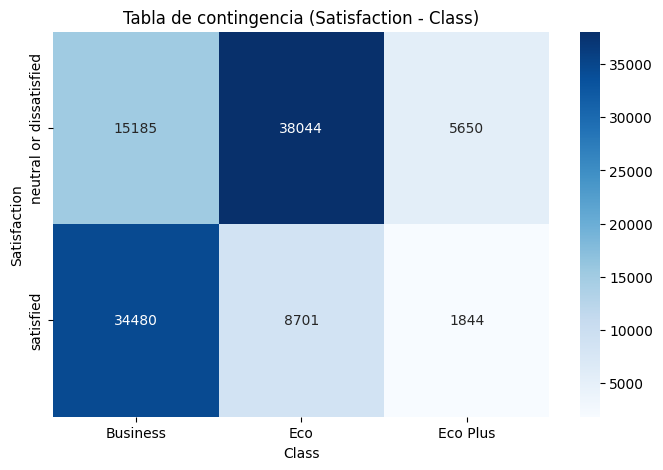

In [79]:
plt.figure(figsize=(8, 5))
cross_tab = pd.crosstab(df_train['satisfaction'], df_train['Class'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Tabla de contingencia (Satisfaction - Class)')
plt.xlabel('Class')
plt.ylabel('Satisfaction')
plt.show()

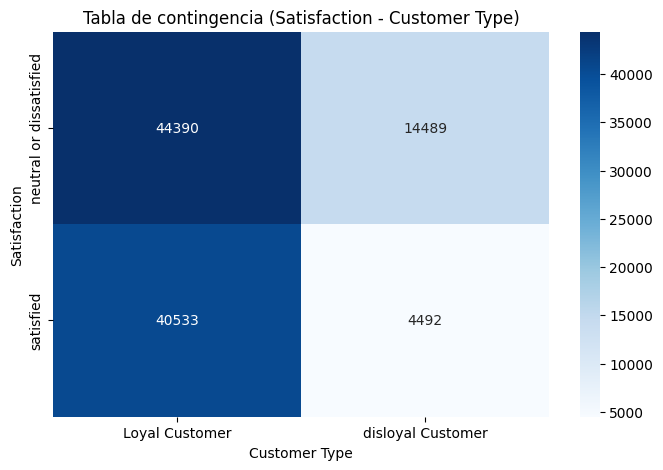

In [80]:
plt.figure(figsize=(8, 5))
cross_tab = pd.crosstab(df_train['satisfaction'], df_train['Customer Type'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Tabla de contingencia (Satisfaction - Customer Type)')
plt.xlabel('Customer Type')
plt.ylabel('Satisfaction')
plt.show()

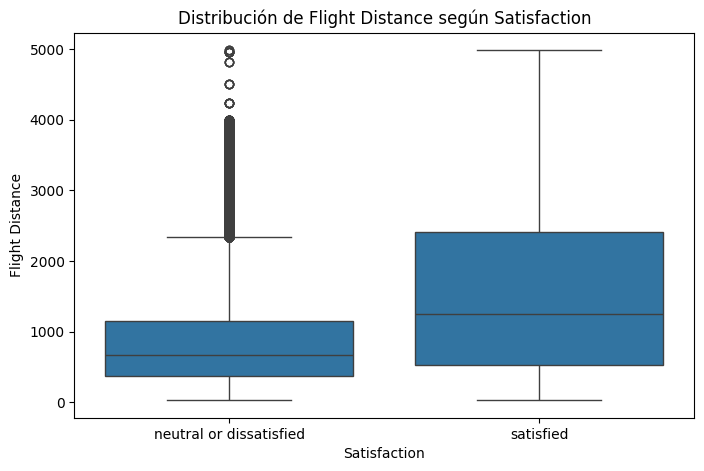

In [81]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_train,
    x="satisfaction",
    y="Flight Distance"

)

plt.title("Distribución de Flight Distance según Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Flight Distance")
plt.show()